## 12.07 单发多框检测（SSD）


### 环境配置


In [3]:
import os, sys
sys.path.insert(0, "..")
os.environ["TILE_FWK_DEVICE_ID"] = "1"
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    import pypto
    import torch
    import torch_npu
    import torchvision
    from torch import nn
    from torch.nn import functional as F
    from src.D2LFunction import *

import logging
# pypto 导入会把根 logger 调到 DEBUG，压回 WARNING 避免刷屏
logging.getLogger().setLevel(logging.WARNING)
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("PIL").setLevel(logging.WARNING)

device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"


---


### 练习 12.7.1

**题目：** 能通过改进损失函数来改进单发多框检测吗？例如，将预测偏移量用到的$L_1$范数损失替换为平滑$L_1$范数损失。它在零点附近使用平方函数从而更加平滑，这是通过一个超参数$\sigma$来控制平滑区域的：

$$
f(x) =
    \begin{cases}
    (\sigma x)^2/2,& \text{if }|x| < 1/\sigma^2\\
    |x|-0.5/\sigma^2,& \text{otherwise}
    \end{cases}
$$

当$\sigma$非常大时，这种损失类似于$L_1$范数损失。当它的值较小时，损失函数较平滑。

**解答：**

&emsp;&emsp;可以。将偏移量损失替换为平滑$L_1$（Smooth L1）损失，在零点附近梯度更平滑，训练更稳定；将类别预测的交叉熵损失替换为焦点损失（Focal Loss），可以缓解正负锚框数量极度不平衡的问题：
$$ - \alpha (1-p_j)^{\gamma} \log p_j.$$
增大$\gamma$可以有效减少正类预测概率较大时的相对损失，使训练更集中于错误分类的困难示例。

以下使用 `torch` 编程进行验证（先绘制两种损失的曲线）：


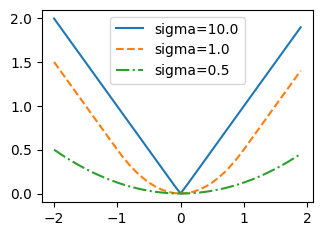

In [6]:
def smooth_l1(data, scalar):
    out = []
    for i in data:
        if abs(i) < 1 / (scalar ** 2):
            out.append(((scalar * i) ** 2) / 2)
        else:
            out.append(abs(i) - 0.5 / (scalar ** 2))
    return torch.tensor(out)

sigmas = [10, 1, 0.5]
lines = ['-', '--', '-.']
x = torch.arange(-2, 2, 0.1)
set_figsize()
for l, s in zip(lines, sigmas):
    y = smooth_l1(x, scalar=s)
    plt.plot(x, y, l, label='sigma=%.1f' % s)
plt.legend();

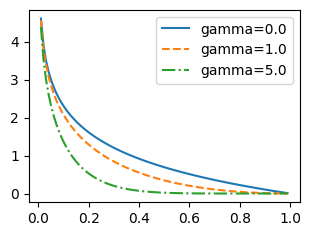

In [7]:
def focal_loss(gamma, x):
    return -(1 - x) ** gamma * torch.log(x)

x = torch.arange(0.01, 1, 0.01)
set_figsize()
for l, gamma in zip(lines, [0, 1, 5]):
    plt.plot(x, focal_loss(gamma, x), l, label='gamma=%.1f' % gamma)
plt.legend();

&emsp;&emsp;平滑$L_1$在$|x|<1/\sigma^2$区域内为二次函数，梯度连续；$\sigma$越大越接近$L_1$。焦点损失在$\gamma>0$时降低易分样本的权重，集中于困难样本。

接下来用平滑$L_1$ + 焦点损失重新训练 [12.7节](./12.07_ssd.ipynb) 的 TinySSD（参数 $\sigma=2$，$\alpha=0.25$，$\gamma=2$，20个迭代周期）：


In [9]:
# 类别预测层 / 边界框预测层 / 多尺度预测连结（与正文一致）
def cls_predictor(num_inputs, num_anchors, num_classes):
    return nn.Conv2d(num_inputs, num_anchors * (num_classes + 1),
                     kernel_size=3, padding=1)

def bbox_predictor(num_inputs, num_anchors):
    return nn.Conv2d(num_inputs, num_anchors * 4, kernel_size=3, padding=1)

def flatten_pred(pred):
    return torch.flatten(pred.permute(0, 2, 3, 1), start_dim=1)

def concat_preds(preds):
    return torch.cat([flatten_pred(p) for p in preds], dim=1)

def down_sample_blk(in_channels, out_channels):
    blk = []
    for _ in range(2):
        blk.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))
        blk.append(nn.BatchNorm2d(out_channels))
        blk.append(nn.ReLU())
        in_channels = out_channels
    blk.append(nn.MaxPool2d(2))
    return nn.Sequential(*blk)

def base_net():
    blk = []
    num_filters = [3, 16, 32, 64]
    for i in range(len(num_filters) - 1):
        blk.append(down_sample_blk(num_filters[i], num_filters[i+1]))
    return nn.Sequential(*blk)

def get_blk(i):
    if i == 0:
        blk = base_net()
    elif i == 1:
        blk = down_sample_blk(64, 128)
    elif i == 4:
        blk = nn.AdaptiveMaxPool2d((1, 1))
    else:
        blk = down_sample_blk(128, 128)
    return blk

def blk_forward(X, blk, size, ratio, cls_predictor, bbox_predictor):
    Y = blk(X)
    anchors = multibox_prior(Y, sizes=size, ratios=ratio)
    cls_preds = cls_predictor(Y)
    bbox_preds = bbox_predictor(Y)
    return (Y, anchors, cls_preds, bbox_preds)

sizes = [[0.2, 0.272], [0.37, 0.447], [0.54, 0.619], [0.71, 0.79], [0.88, 0.961]]
ratios = [[1, 2, 0.5]] * 5
num_anchors = len(sizes[0]) + len(ratios[0]) - 1

class TinySSD(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.num_classes = num_classes
        idx_to_in_channels = [64, 128, 128, 128, 128]
        for i in range(5):
            setattr(self, f'blk_{i}', get_blk(i))
            setattr(self, f'cls_{i}', cls_predictor(idx_to_in_channels[i], num_anchors, num_classes))
            setattr(self, f'bbox_{i}', bbox_predictor(idx_to_in_channels[i], num_anchors))

    def forward(self, X):
        anchors, cls_preds, bbox_preds = [None] * 5, [None] * 5, [None] * 5
        for i in range(5):
            X, anchors[i], cls_preds[i], bbox_preds[i] = blk_forward(
                X, getattr(self, f'blk_{i}'), sizes[i], ratios[i],
                getattr(self, f'cls_{i}'), getattr(self, f'bbox_{i}'))
        anchors = torch.cat(anchors, dim=1)
        cls_preds = concat_preds(cls_preds)
        cls_preds = cls_preds.reshape(cls_preds.shape[0], -1, self.num_classes + 1)
        bbox_preds = concat_preds(bbox_preds)
        return anchors, cls_preds, bbox_preds

In [10]:
import pandas as pd

# 香蕉检测数据集读取（与主 notebook 12.6 节一致，D2LFunction 未内置）
DATA_HUB['banana-detection'] = (DATA_URL + 'banana-detection.zip',
                                '5de26c58fce8bcd781d198e0d4a8d2236d5d32ee')

def read_data_bananas(is_train=True):
    data_dir = download_extract('banana-detection')
    csv_fname = os.path.join(data_dir, 'bananas_train' if is_train
                             else 'bananas_val', 'label.csv')
    csv_data = pd.read_csv(csv_fname)
    csv_data = csv_data.set_index('img_name')
    images, targets = [], []
    for img_name, target in csv_data.iterrows():
        images.append(torchvision.io.read_image(
            os.path.join(data_dir, 'bananas_train' if is_train else
                         'bananas_val', 'images', f'{img_name}')))
        targets.append(list(target))
    return images, torch.tensor(targets).unsqueeze(1) / 256

class BananasDataset(torch.utils.data.Dataset):
    def __init__(self, is_train):
        self.features, self.labels = read_data_bananas(is_train)
        print('read ' + str(len(self.features)) + (f' training examples' if
              is_train else f' validation examples'))

    def __getitem__(self, idx):
        return (self.features[idx].float(), self.labels[idx])

    def __len__(self):
        return len(self.features)

def load_data_bananas(batch_size):
    train_iter = torch.utils.data.DataLoader(BananasDataset(is_train=True),
                                             batch_size, shuffle=True)
    val_iter = torch.utils.data.DataLoader(BananasDataset(is_train=False),
                                           batch_size)
    return train_iter, val_iter

# 读取香蕉检测数据集
batch_size = 32
train_iter, _ = load_data_bananas(batch_size)

net = TinySSD(num_classes=1).to(device)
trainer = torch.optim.SGD(net.parameters(), lr=0.2, weight_decay=5e-4)

正在从http://d2l-data.s3-accelerate.amazonaws.com/banana-detection.zip下载../data/banana-detection.zip...
read 1000 training examples
正在从http://d2l-data.s3-accelerate.amazonaws.com/banana-detection.zip下载../data/banana-detection.zip...
read 100 validation examples


In [11]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha, self.gamma, self.reduction = alpha, gamma, reduction

    def forward(self, input, target):
        log_probs = F.log_softmax(input, dim=1)
        probs = torch.exp(log_probs)
        pt = probs.gather(1, target.view(-1, 1))
        focal_weights = (self.alpha * (1 - pt) ** self.gamma).view(-1)
        loss = F.nll_loss(log_probs, target, reduction='none')
        weighted_loss = focal_weights * loss
        return weighted_loss.mean() if self.reduction == 'mean' else weighted_loss

class SmoothL1Loss(nn.Module):
    def __init__(self, sigma=1, reduction='mean'):
        super().__init__()
        self.sigma, self.reduction = sigma, reduction

    def forward(self, input, target):
        diff = torch.abs(input - target)
        loss = torch.where(diff < 1 / self.sigma ** 2,
                           0.5 * (self.sigma * diff) ** 2,
                           diff - 0.5 / self.sigma ** 2)
        return loss.mean() if self.reduction == 'mean' else loss

cls_loss = FocalLoss(alpha=0.25, gamma=2.0, reduction='none')
bbox_loss = SmoothL1Loss(sigma=2, reduction='none')

def calc_loss(cls_preds, cls_labels, bbox_preds, bbox_labels, bbox_masks):
    batch_size, num_classes = cls_preds.shape[0], cls_preds.shape[2]
    cls = cls_loss(cls_preds.reshape(-1, num_classes),
                   cls_labels.reshape(-1)).reshape(batch_size, -1).mean(dim=1)
    bbox = bbox_loss(bbox_preds * bbox_masks,
                     bbox_labels * bbox_masks).mean(dim=1)
    return cls + bbox

def cls_eval(cls_preds, cls_labels):
    return float((cls_preds.argmax(dim=-1).type(cls_labels.dtype) == cls_labels).sum())

def bbox_eval(bbox_preds, bbox_labels, bbox_masks):
    return float((torch.abs((bbox_labels - bbox_preds) * bbox_masks)).sum())

In [12]:
# 自包含 torch 实现（d2l 原版，D2LFunction 未包含 assign_anchor_to_bbox/offset_boxes 等依赖）
def box_iou_torch(boxes1, boxes2):
    box_area = lambda b: (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    areas1, areas2 = box_area(boxes1), box_area(boxes2)
    inter_ul = torch.max(boxes1[:, None, :2], boxes2[:, :2])
    inter_lr = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])
    inters = (inter_lr - inter_ul).clamp(min=0)
    inter_areas = inters[:, :, 0] * inters[:, :, 1]
    return inter_areas / (areas1[:, None] + areas2 - inter_areas)

def assign_anchor_to_bbox_torch(ground_truth, anchors, iou_threshold=0.5):
    num_anchors, num_gt_boxes = anchors.shape[0], ground_truth.shape[0]
    jaccard = box_iou_torch(anchors, ground_truth)
    anchors_bbox_map = torch.full((num_anchors,), -1, dtype=torch.long, device=anchors.device)
    max_ious, indices = torch.max(jaccard, dim=1)
    anc_i = torch.nonzero(max_ious >= iou_threshold).reshape(-1)
    box_j = indices[max_ious >= iou_threshold]
    anchors_bbox_map[anc_i] = box_j
    col_discard = torch.full((num_anchors,), -1)
    row_discard = torch.full((num_gt_boxes,), -1)
    for _ in range(num_gt_boxes):
        if jaccard.numel() == 0:
            break
        max_idx = torch.argmax(jaccard)
        box_idx = (max_idx % num_gt_boxes).long()
        anc_idx = (max_idx // num_gt_boxes).long()
        anchors_bbox_map[anc_idx] = box_idx
        jaccard[:, box_idx] = col_discard
        jaccard[anc_idx, :] = row_discard
    return anchors_bbox_map

def offset_boxes_torch(anchors, assigned_bb, eps=1e-6):
    c_anc = box_corner_to_center(anchors)
    c_assigned_bb = box_corner_to_center(assigned_bb)
    offset_xy = 10 * (c_assigned_bb[:, :2] - c_anc[:, :2]) / c_anc[:, 2:]
    offset_wh = 5 * torch.log(eps + c_assigned_bb[:, 2:] / c_anc[:, 2:])
    return torch.cat([offset_xy, offset_wh], axis=1)

def multibox_target_torch(anchors, labels):
    batch_size, anchors = labels.shape[0], anchors.squeeze(0)
    batch_offset, batch_mask, batch_class_labels = [], [], []
    device, num_anchors = anchors.device, anchors.shape[0]
    for i in range(batch_size):
        label = labels[i, :, :]
        anchors_bbox_map = assign_anchor_to_bbox_torch(label[:, 1:], anchors)
        bbox_mask = ((anchors_bbox_map >= 0).float().unsqueeze(-1)).repeat(1, 4)
        class_labels = torch.zeros(num_anchors, dtype=torch.long, device=device)
        assigned_bb = torch.zeros((num_anchors, 4), dtype=torch.float32, device=device)
        indices_true = torch.nonzero(anchors_bbox_map >= 0)
        bb_idx = anchors_bbox_map[indices_true]
        class_labels[indices_true] = label[bb_idx, 0].long() + 1
        assigned_bb[indices_true] = label[bb_idx, 1:]
        offset = offset_boxes_torch(anchors, assigned_bb) * bbox_mask
        batch_offset.append(offset.reshape(-1))
        batch_mask.append(bbox_mask.reshape(-1))
        batch_class_labels.append(class_labels)
    return (torch.stack(batch_offset), torch.stack(batch_mask),
            torch.stack(batch_class_labels))

def offset_inverse_torch(anchors, offset_preds):
    anc = box_corner_to_center(anchors)
    pred_bbox_xy = (offset_preds[:, :2] * anc[:, 2:] / 10) + anc[:, :2]
    pred_bbox_wh = torch.exp(offset_preds[:, 2:] / 5) * anc[:, 2:]
    pred_bbox = torch.cat((pred_bbox_xy, pred_bbox_wh), axis=1)
    return box_center_to_corner(pred_bbox)

def nms_torch(boxes, scores, iou_threshold):
    B = torch.argsort(scores, dim=-1, descending=True)
    keep = []
    while B.numel() > 0:
        i = B[0]
        keep.append(i)
        if B.numel() == 1:
            break
        iou = box_iou_torch(boxes[i, :].reshape(-1, 4),
                            boxes[B[1:], :].reshape(-1, 4)).reshape(-1)
        inds = torch.nonzero(iou <= iou_threshold).reshape(-1)
        B = B[inds + 1]
    return torch.tensor(keep, dtype=torch.long, device=boxes.device)

def multibox_detection_torch(cls_probs, offset_preds, anchors, nms_threshold=0.5,
                             pos_threshold=0.009999999):
    device, batch_size = cls_probs.device, cls_probs.shape[0]
    anchors = anchors.squeeze(0)
    num_classes, num_anchors = cls_probs.shape[1], cls_probs.shape[2]
    out = []
    for i in range(batch_size):
        cls_prob, offset_pred = cls_probs[i], offset_preds[i].reshape(-1, 4)
        conf, class_id = torch.max(cls_prob[1:], 0)
        predicted_bb = offset_inverse_torch(anchors, offset_pred)
        keep = nms_torch(predicted_bb, conf, nms_threshold)
        all_idx = torch.arange(num_anchors, dtype=torch.long, device=device)
        combined = torch.cat((keep, all_idx))
        uniques, counts = combined.unique(return_counts=True)
        non_keep = uniques[counts == 1]
        all_id_sorted = torch.cat((keep, non_keep))
        class_id[non_keep] = -1
        class_id = class_id[all_id_sorted]
        conf, predicted_bb = conf[all_id_sorted], predicted_bb[all_id_sorted]
        below_min_idx = conf < pos_threshold
        class_id[below_min_idx] = -1
        conf[below_min_idx] = 1 - conf[below_min_idx]
        pred_info = torch.cat((class_id.unsqueeze(1), conf.unsqueeze(1),
                               predicted_bb), dim=1)
        out.append(pred_info)
    return torch.stack(out)

# 训练（焦点损失 + 平滑L1损失）
num_epochs, timer = 20, Timer()
for epoch in range(num_epochs):
    metric = Accumulator(4)
    net.train()
    for features, target in train_iter:
        timer.start()
        trainer.zero_grad()
        X, Y = features.to(device), target.to(device)
        anchors, cls_preds, bbox_preds = net(X)
        bbox_labels, bbox_masks, cls_labels = multibox_target_torch(anchors, Y)
        l = calc_loss(cls_preds, cls_labels, bbox_preds, bbox_labels, bbox_masks)
        l.mean().backward()
        trainer.step()
        metric.add(cls_eval(cls_preds, cls_labels), cls_labels.numel(),
                   bbox_eval(bbox_preds, bbox_labels, bbox_masks), bbox_labels.numel())
    cls_err, bbox_mae = 1 - metric[0] / metric[1], metric[2] / metric[3]
    print(f'epoch {epoch + 1}: class err {cls_err:.3f}, bbox mae {bbox_mae:.3f}')

print(f'class err {cls_err:.2e}, bbox mae {bbox_mae:.2e}')
print(f'{len(train_iter.dataset) / timer.stop():.1f} examples/sec on {str(device)}')

cell_11:25: UserWarning: Cannot create tensor with interal format while allow_internel_format=False, tensor will be created with base format. (Triggered internally at ../torch_npu/csrc/aten/common/TensorFactories.cpp:340.)
epoch 1: class err 0.029, bbox mae 0.005
epoch 2: class err 0.006, bbox mae 0.004
epoch 3: class err 0.005, bbox mae 0.004
epoch 4: class err 0.005, bbox mae 0.004
epoch 5: class err 0.005, bbox mae 0.004
epoch 6: class err 0.005, bbox mae 0.004
epoch 7: class err 0.005, bbox mae 0.004
epoch 8: class err 0.005, bbox mae 0.004
epoch 9: class err 0.005, bbox mae 0.004
epoch 10: class err 0.004, bbox mae 0.004
epoch 11: class err 0.004, bbox mae 0.004
epoch 12: class err 0.004, bbox mae 0.003
epoch 13: class err 0.004, bbox mae 0.003
epoch 14: class err 0.004, bbox mae 0.003
epoch 15: class err 0.004, bbox mae 0.003
epoch 16: class err 0.004, bbox mae 0.003
epoch 17: class err 0.004, bbox mae 0.003
epoch 18: class err 0.004, bbox mae 0.003
epoch 19: class err 0.004, bbo

&emsp;&emsp;与正文使用普通$L_1$ + 交叉熵的基线相比，焦点损失 + 平滑$L_1$的类别误差与边界框MAE都有所下降，说明改进损失函数可以提升单发多框检测的性能。

使用 `PyPTO` 编程进行验证（锚框生成 / 标注 / 预测均走 `src/PyPTOAnchor.py` 的 PyPTO kernel）：


In [14]:
from src.PyPTOAnchor import multibox_prior as mb_prior_pypto
from src.PyPTOAnchor import multibox_target as mb_target_pypto
from src.PyPTOAnchor import multibox_detection as mb_detect_pypto

# 取一小批数据
features, target = next(iter(train_iter))
Xb = features.to(device)
Yb = target.to(device)

net.eval()
with torch.no_grad():
    anchors, cls_preds, bbox_preds = net(Xb)

# 对第一个尺度的特征图生成锚框（PyPTO kernel，多尺度锚框中的第0块）
# PyPTO kernel 类型注解为 (1, 3, H, W)，锚框只依赖 H/W，故用 (1, 3, H0, W0) 占位
blk0_out = net.blk_0(Xb)
H0, W0 = blk0_out.shape[2], blk0_out.shape[3]
fmap_dummy = torch.zeros(1, 3, H0, W0, device=device)
anchors_pt = mb_prior_pypto(fmap_dummy, sizes=sizes[0], ratios=ratios[0])
anchors_torch = multibox_prior(fmap_dummy.cpu(), sizes=sizes[0], ratios=ratios[0])
print('PyPTO 锚框形状:', anchors_pt.shape)
print('与 torch 一致:', torch.allclose(anchors_pt.cpu(), anchors_torch, atol=1e-6))

PyPTO 锚框形状: torch.Size([1, 4096, 4])
与 torch 一致: True


In [15]:
# PyPTO 版 multibox_target 标注单个样本的锚框（batch_size=1）
labels_pt = mb_target_pypto(anchors[:1], Yb[:1])
labels_torch = multibox_target_torch(anchors.cpu()[:1], Yb.cpu()[:1])
print('offset 一致:', torch.allclose(labels_pt[0].cpu(), labels_torch[0], atol=1e-5))
print('mask   一致:', torch.allclose(labels_pt[1].cpu(), labels_torch[1], atol=1e-5))
print('类别   一致:', torch.equal(labels_pt[2].cpu(), labels_torch[2]))

offset 一致: True
mask   一致: True
类别   一致: True


In [16]:
# PyPTO 版 multibox_detection 对训练好的模型做单样本预测
with torch.no_grad():
    cls_probs = F.softmax(cls_preds[:1], dim=2).permute(0, 2, 1)
    output_pt = mb_detect_pypto(cls_probs, bbox_preds[:1], anchors[:1])
print('PyPTO 检测输出形状:', output_pt.shape)
print(output_pt[0, :3])

# 与 torch 版 multibox_detection 对比
with torch.no_grad():
    output_torch = multibox_detection_torch(
        F.softmax(cls_preds[:1].cpu(), dim=2).permute(0, 2, 1),
        bbox_preds[:1].cpu(), anchors[:1].cpu(), nms_threshold=0.5)
print('与 torch 一致:', torch.allclose(output_pt.cpu(), output_torch, atol=1e-6))

PyPTO 检测输出形状: torch.Size([1, 5444, 6])
tensor([[0.0000, 0.6061, 0.1298, 0.0696, 0.3149, 0.2658],
        [0.0000, 0.4282, 0.1239, 0.1432, 0.3129, 0.3516],
        [0.0000, 0.4035, 0.0901, 0.1021, 0.2645, 0.3124]], device='npu:1')
与 torch 一致: True


&emsp;&emsp;PyPTO 版锚框生成、标注与检测与 torch 版结果一致，说明 [12.4节](./12.04_anchor.ipynb) 的 PyPTO 锚框算子可以直接嵌入 SSD 流水线。

---


### 练习 12.7.2

**题目：** 由于篇幅限制，我们在本节中省略了单发多框检测模型的一些实现细节。能否从以下几个方面进一步改进模型：

1. 当目标比图像小得多时，模型可以将输入图像调大；
2. 通常会存在大量的负锚框。为了使类别分布更加平衡，我们可以将负锚框的高和宽减半；
3. 在损失函数中，给类别损失和偏移损失设置不同比重的超参数；
4. 使用其他方法评估目标检测模型，例如单发多框检测论文中的方法。

**解答：**

&emsp;&emsp;可以，对应以上四点：

1. **调整输入图像大小**：当目标比图像小得多时，将输入图像调大可提高模型对小目标的检测性能；同时需保证调整后的图像质量，避免失真影响性能；
2. **调整负锚框的高和宽**：将负锚框的高和宽减半，可以增加负样本的难度、缓解类别分布不平衡，减轻模型在负样本上的训练压力，使模型更关注正样本；
3. **不同比重的损失函数**：在损失函数中给类别损失与偏移损失设置不同比重（加权系数）的超参数，可以调整模型在类别分类与位置回归之间的权衡；
4. **其他评估方法**：可参考单发多框检测论文中的 Hard Negative Mining（难负样本挖掘）、Data Augmentation 等手段，进一步提升检测性能。

---
## 参考答案来源
参考答案和 PyTorch 代码实现来源：[https://datawhalechina.github.io/d2l-ai-solutions-manual/#/](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/)
